# Clean Knowledge Distillation Pipeline Demo

This notebook demonstrates a streamlined knowledge distillation pipeline that uses a pre-trained ResNet50 teacher model to train a lightweight student model.

## Features:
- Uses existing trained teacher model (`best_teacher_model.pth`)
- Balanced sampling for handling class imbalance
- Advanced data augmentation
- Clean, minimal dependencies
- Comprehensive loss tracking (soft + hard targets)
- Real-time training visualization


In [1]:
# Import required libraries
import os
import sys
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Any, Optional, Tuple
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Add current directory to path
sys.path.append(str(Path.cwd()))

# Import our clean distillation pipeline
from clean_distillation_pipeline import (
    CleanDistillationPipeline,
    load_dataset_from_csv
)

print("✅ Libraries imported successfully!")


/home/madc0der/projects/CRPlayer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported successfully!


## 1. Load Dataset

Load your dataset from CSV file. The pipeline will automatically detect class columns and handle the data loading.


In [2]:
BATCH_SIZE = 128

In [3]:
from dataset_inspector import DatasetAnalyzer
from data_loader import DatasetConfig
# Initialize data configuration
data_config = DatasetConfig(
    annotation_api_url="http://localhost:5000",
    data_root="./data",
    output_dir="./output",
    image_size=(224, 224),
    batch_size=BATCH_SIZE,
    num_workers=4,
    test_size=0.2,
    val_size=0.1,
    random_state=42
)

# Initialize dataset analyzer
analyzer = DatasetAnalyzer(data_config)
#analyzer.generate_comprehensive_report(1)

In [4]:
# Configuration
teacher_model_path = "best_teacher_model.pth"  # Path to your trained teacher model
csv_path = "./data/labeled_data.csv"  # Path to your dataset CSV
data_root = "../../data"  # Root directory for images

# Load dataset
print("Loading dataset...")
df, class_names, class_id_col = load_dataset_from_csv(csv_path, data_root)
num_classes = len(class_names)

print(f"\nDataset Summary:")
print(f"Total samples: {len(df)}")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Class ID column: {class_id_col}")

Loading dataset...
Dataset loaded: 2319 samples, 21 classes
Class names: ['match_battle', 'collections_decks', 'match_end', 'load_screen', 'open_box', 'open_confirm', 'main', 'trophy_road', 'open_chest', 'shop_other', 'app_load', 'shop_daily', 'shop_confirm', 'collection_cards', 'collection_other', 'clans_empty', 'clans_search', 'social_friends', 'match_search', 'match_preview', 'relogin_screen']

Dataset Summary:
Total samples: 2319
Number of classes: 21
Class names: ['match_battle', 'collections_decks', 'match_end', 'load_screen', 'open_box', 'open_confirm', 'main', 'trophy_road', 'open_chest', 'shop_other', 'app_load', 'shop_daily', 'shop_confirm', 'collection_cards', 'collection_other', 'clans_empty', 'clans_search', 'social_friends', 'match_search', 'match_preview', 'relogin_screen']
Class ID column: class_id


## 2. Initialize Distillation Pipeline

Create the distillation pipeline with your trained teacher model.


In [5]:
# Initialize distillation pipeline
print("Initializing distillation pipeline...")
pipeline = CleanDistillationPipeline(
    teacher_model_path=teacher_model_path,
    num_classes=num_classes,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"\nPipeline initialized successfully!")
print(f"Device: {pipeline.device}")
print(f"Number of classes: {num_classes}")


Initializing distillation pipeline...


/home/madc0der/projects/CRPlayer/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/madc0der/projects/CRPlayer/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Distillation pipeline initialized on cuda
Teacher model loaded from: best_teacher_model.pth
Student model created with 458,421 parameters

Pipeline initialized successfully!
Device: cuda
Number of classes: 21


## 3. Create Data Loaders

Create training, validation, and test data loaders with balanced sampling and augmentation.


In [6]:
# Create data loaders
print("Creating data loaders...")
train_loader, val_loader, test_loader, train_df, val_df, test_df = pipeline.create_data_loaders(
    df, 
    data_root=data_root, 
    batch_size=BATCH_SIZE, 
    test_size=0.2, 
    val_size=0.1, 
    class_id_col=class_id_col
)

# print(f"\nData Split Summary:")
# print(f"Training samples: {len(train_df)}")
# print(f"Validation samples: {len(val_df)}")
# print(f"Test samples: {len(test_df)}")
# print(f"Total samples: {len(train_df) + len(val_df) + len(test_df)}")

# Show class distribution in each split
# print(f"\nClass Distribution:")
# for split_name, split_df in [("Training", train_df), ("Validation", val_df), ("Test", test_df)]:
#     print(f"\n{split_name} set:")
#     split_counts = split_df[class_id_col].value_counts().sort_index()
#     for class_id, count in split_counts.items():
#         class_name = class_names[int(class_id)] if class_id < len(class_names) else f"class_{class_id}"
#         percentage = (count / len(split_df)) * 100
#         print(f"  {class_name}: {count} samples ({percentage:.1f}%)")


Creating data loaders...
Preloading images...


Loading images: 100%|██████████| 1623/1623 [00:10<00:00, 150.53it/s]


Preloaded 1623 images
Preloading images...


Loading images: 100%|██████████| 232/232 [00:01<00:00, 151.38it/s]


Preloaded 232 images
Preloading images...


Loading images: 100%|██████████| 464/464 [00:03<00:00, 153.00it/s]


Preloaded 464 images


torch.Size([3, 224, 224]) torch.float32 tensor(1)
torch.Size([3, 224, 224]) torch.float32 tensor(10)
torch.Size([3, 224, 224]) torch.float32 tensor(2)
torch.Size([3, 224, 224]) torch.float32 tensor(19)
torch.Size([3, 224, 224]) torch.float32 tensor(12)
torch.Size([3, 224, 224]) torch.float32 tensor(12)
torch.Size([3, 224, 224]) torch.float32 tensor(2)
torch.Size([3, 224, 224]) torch.float32 tensor(2)


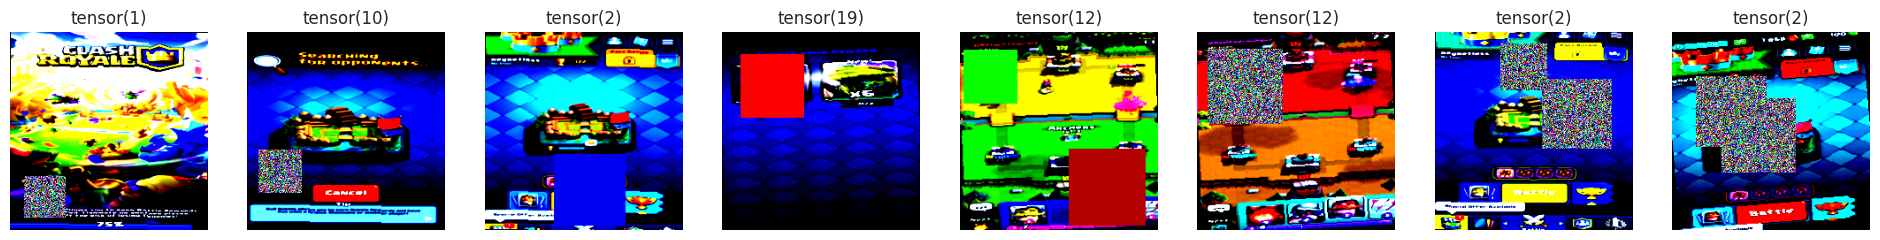

In [7]:
def show_dataset_samples(dataloader, n=8):
  """
  Visualize n random samples from a PyTorch dataset.

  Args:
    dataset (torch.utils.data.Dataset): Your dataset with __getitem__ implemented.
    n (int): Number of images to show.
  """
  dataset = dataloader.dataset
  indices = np.random.randint(0, len(dataset), (n,))
  fig, axes = plt.subplots(1, n, figsize=(3*n, 3))

  if n == 1:
    axes = [axes]

  for ax, idx in zip(axes, indices):
    img, label = dataset[idx]
    print(img.shape, img.dtype, label)

    # If your dataset returns tensors, convert them for plotting
    if torch.is_tensor(img):
      img = img.detach().cpu()
      if img.ndim == 3 and img.shape[0] in (1, 3):  # CHW format
        img = img.permute(1, 2, 0)  # to HWC
      img = img.numpy()

    ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
    ax.set_title(str(label))
    ax.axis("off")

  plt.show()

show_dataset_samples(train_loader)

In [8]:
# Add this diagnostic cell after your data loaders are created

# DIAGNOSTIC: Check class labels and data integrity
print("=== DATA DIAGNOSTIC ===")
print(f"Original dataset shape: {df.shape}")
print(f"Class ID column: {class_id_col}")
print(f"Number of classes: {num_classes}")

# Check unique values in class column
unique_class_ids = df[class_id_col].unique()
print(f"\nUnique class IDs in dataset: {sorted(unique_class_ids)}")
print(f"Min class ID: {min(unique_class_ids)}")
print(f"Max class ID: {max(unique_class_ids)}")
print(f"Number of unique class IDs: {len(unique_class_ids)}")

# Check if class IDs are 0-based
if min(unique_class_ids) == 0 and max(unique_class_ids) == len(unique_class_ids) - 1:
    print("✅ Class IDs are properly 0-based")
else:
    print("❌ Class IDs are NOT 0-based - this will cause CUDA errors!")

# Check for any non-integer or NaN values
non_numeric = df[class_id_col].isna().sum()
print(f"NaN values in class column: {non_numeric}")

# Check data splits
print(f"\n=== DATA SPLITS ===")
for split_name, split_df in [("Training", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{split_name} set:")
    print(f"  Samples: {len(split_df)}")
    unique_in_split = split_df[class_id_col].unique()
    print(f"  Unique class IDs: {sorted(unique_in_split)}")
    print(f"  Min class ID: {min(unique_in_split)}")
    print(f"  Max class ID: {max(unique_in_split)}")
    
    # Check if this split has too many unique classes relative to samples
    unique_ratio = len(unique_in_split) / len(split_df)
    print(f"  Unique classes / total samples ratio: {unique_ratio:.3f}")
    if unique_ratio > 0.5:
        print(f"  ⚠️  WARNING: This split has >50% unique classes - sklearn will warn!")

# Check a few actual samples from the data loader
print(f"\n=== SAMPLE BATCH CHECK ===")
sample_batch = next(iter(train_loader))
images, labels = sample_batch
print(f"Batch shape: images={images.shape}, labels={labels.shape}")
print(f"Label values in batch: {labels.numpy()}")
print(f"Label data type: {labels.dtype}")
print(f"Min label in batch: {labels.min().item()}")
print(f"Max label in batch: {labels.max().item()}")

# Check if labels are within valid range
valid_labels = (labels >= 0) & (labels < num_classes)
print(f"Valid labels in batch: {valid_labels.sum().item()}/{len(labels)}")
if not valid_labels.all():
    print(f"❌ Found invalid labels! This will cause CUDA errors!")
    invalid_labels = labels[~valid_labels]
    print(f"Invalid label values: {invalid_labels.numpy()}")

=== DATA DIAGNOSTIC ===
Original dataset shape: (2319, 6)
Class ID column: class_id
Number of classes: 21

Unique class IDs in dataset: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0)]
Min class ID: 0.0
Max class ID: 20.0
Number of unique class IDs: 21
✅ Class IDs are properly 0-based
NaN values in class column: 0

=== DATA SPLITS ===

Training set:
  Samples: 1623
  Unique class IDs: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16

## 4. Train Student Model

Train the lightweight student model using knowledge distillation from the teacher model.


In [9]:
import warnings
from sklearn.exceptions import DataConversionWarning

# Suppress the specific sklearn warning about unique classes
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.metrics._classification")

In [15]:
# Train student model
print("Starting distillation training...")
print("This will train the student model using knowledge from the teacher model.")
print("The loss combines both soft targets (teacher predictions) and hard targets (ground truth).")

history, best_val_f1 = pipeline.train_student(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=2048,  # Adjust as needed
    learning_rate=1e-4,
    weight_decay=1e-4
)

print(f"\nTraining completed!")
print(f"Best validation F1 score: {best_val_f1:.4f}")


Starting distillation training...
This will train the student model using knowledge from the teacher model.
The loss combines both soft targets (teacher predictions) and hard targets (ground truth).
Starting distillation training for 2048 epochs...


Epoch  0: Train Loss: 6.3883, Train Acc: 0.4286, Val Loss: 6.0777, Val Acc: 0.6034, Val F1: 0.5731


Epoch  1: Train Loss: 5.6588, Train Acc: 0.6190, Val Loss: 5.9876, Val Acc: 0.6078, Val F1: 0.5773


Epoch  2: Train Loss: 6.1737, Train Acc: 0.7143, Val Loss: 5.9197, Val Acc: 0.6078, Val F1: 0.5773


Epoch  3: Train Loss: 6.1278, Train Acc: 0.5238, Val Loss: 5.8614, Val Acc: 0.6078, Val F1: 0.5773


...

Epoch 2030: Train Loss: 0.6896, Train Acc: 0.9524, Val Loss: 0.4119, Val Acc: 0.9784, Val F1: 0.9731


Epoch 2035: Train Loss: 0.5486, Train Acc: 0.9524, Val Loss: 0.4932, Val Acc: 0.9784, Val F1: 0.9731


Epoch 2040: Train Loss: 0.5579, Train Acc: 0.9524, Val Loss: 0.6028, Val Acc: 0.9784, Val F1: 0.9731


Epoch 2045: Train Loss: 0.3894, Train Acc: 1.0000, Val Loss: 0.6130, Val Acc: 0.9741, Val F1: 0.9675


Training completed! Best validation F1: 0.9827

Training completed!
Best validation F1 score: 0.9827


In [16]:
# Let's manually check what happens during validation
print("=== PREDICTION DEBUGGING ===")

# Get a sample batch from validation loader
val_batch = next(iter(val_loader))
val_images, val_targets = val_batch
val_images, val_targets = val_images.to(pipeline.device), val_targets.to(pipeline.device)

print(f"Validation batch shape: images={val_images.shape}, targets={val_targets.shape}")
print(f"Target values: {val_targets.cpu().numpy()}")
print(f"Target unique values: {torch.unique(val_targets).cpu().numpy()}")

# Get model predictions
pipeline.student_model.eval()
with torch.no_grad():
    student_output = pipeline.student_model(val_images)
    student_predictions = torch.argmax(student_output, dim=1)
    
print(f"Student output shape: {student_output.shape}")
print(f"Student predictions: {student_predictions.cpu().numpy()}")
print(f"Prediction unique values: {torch.unique(student_predictions).cpu().numpy()}")
print(f"Min prediction: {student_predictions.min().item()}")
print(f"Max prediction: {student_predictions.max().item()}")

# Check if predictions are within valid range
valid_predictions = (student_predictions >= 0) & (student_predictions < num_classes)
print(f"Valid predictions: {valid_predictions.sum().item()}/{len(student_predictions)}")

if not valid_predictions.all():
    print("❌ Found invalid predictions!")
    invalid_preds = student_predictions[~valid_predictions]
    print(f"Invalid prediction values: {invalid_preds.cpu().numpy()}")

# Check what sklearn sees
from sklearn.metrics import f1_score
import numpy as np

# Convert to numpy for sklearn
targets_np = val_targets.cpu().numpy()
predictions_np = student_predictions.cpu().numpy()

print(f"\n=== SKLEARN INPUT CHECK ===")
print(f"Targets shape: {targets_np.shape}, unique: {len(np.unique(targets_np))}")
print(f"Predictions shape: {predictions_np.shape}, unique: {len(np.unique(predictions_np))}")
print(f"Target unique values: {np.unique(targets_np)}")
print(f"Prediction unique values: {np.unique(predictions_np)}")

# This is what's causing the warning
unique_ratio = len(np.unique(predictions_np)) / len(predictions_np)
print(f"Unique predictions / total samples ratio: {unique_ratio:.3f}")
if unique_ratio > 0.5:
    print("⚠️  This ratio > 0.5 will trigger sklearn warning!")

# Try f1_score with different settings
try:
    f1_weighted = f1_score(targets_np, predictions_np, average='weighted')
    print(f"F1 score (weighted): {f1_weighted:.4f}")
except Exception as e:
    print(f"Error computing F1 score: {e}")

# Check if there are any extreme values
print(f"\n=== EXTREME VALUES CHECK ===")
print(f"Any negative predictions: {(predictions_np < 0).any()}")
print(f"Any predictions >= num_classes: {(predictions_np >= num_classes).any()}")
print(f"Any NaN predictions: {np.isnan(predictions_np).any()}")
print(f"Any inf predictions: {np.isinf(predictions_np).any()}")

=== PREDICTION DEBUGGING ===
Validation batch shape: images=torch.Size([128, 3, 224, 224]), targets=torch.Size([128])
Target values: [ 2 12  1 12  2  2  8 12 12 12  2  2  2 12  7 12 12  2 12 12  2 12  1  2
  2  2 12  1  0  2  9 12 12 12 12 19  1 12 14 12  2 12  6  5  9  9  6  1
  2  2  6  1  2 12 12 12 12 18  5 12  9 14  2  2  2 12  2  2 12  2 10 12
 12 12  2  2 12  9 15 13 17 12  3 13 12 12  2  2 12 12 12 12  2 19  5 12
 18  1 12 12 12  2 12  4 16  8 12 19  5  7 13  2 10 12 12  5  3 12 12 12
 12 12 12 11  2  2  8 12]
Target unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Student output shape: torch.Size([128, 21])
Student predictions: [ 2 12  1 12  2  2  8 12 12 12  2  2  2 12  7 12 12  2 12 12  2 12  1  2
  2  2 12  1  0  2  9 12 12 12 12 19  1 12 14 12  2 12 19  5  9  9  6  1
  2  2  6  1  2 12 12 12 12  6  5 12  9 14  2  2  2 12  2  2 12  2 10 12
 12 12  2  2 12  9 15 13 17 12  2 13 12 12  2  2 12 12 12 12  2 19  5 12
 18  1 12 12 12  2 12  4 16  8 12 1

## 5. Visualize Training Progress

Plot the training history to see how the student model learned from the teacher.


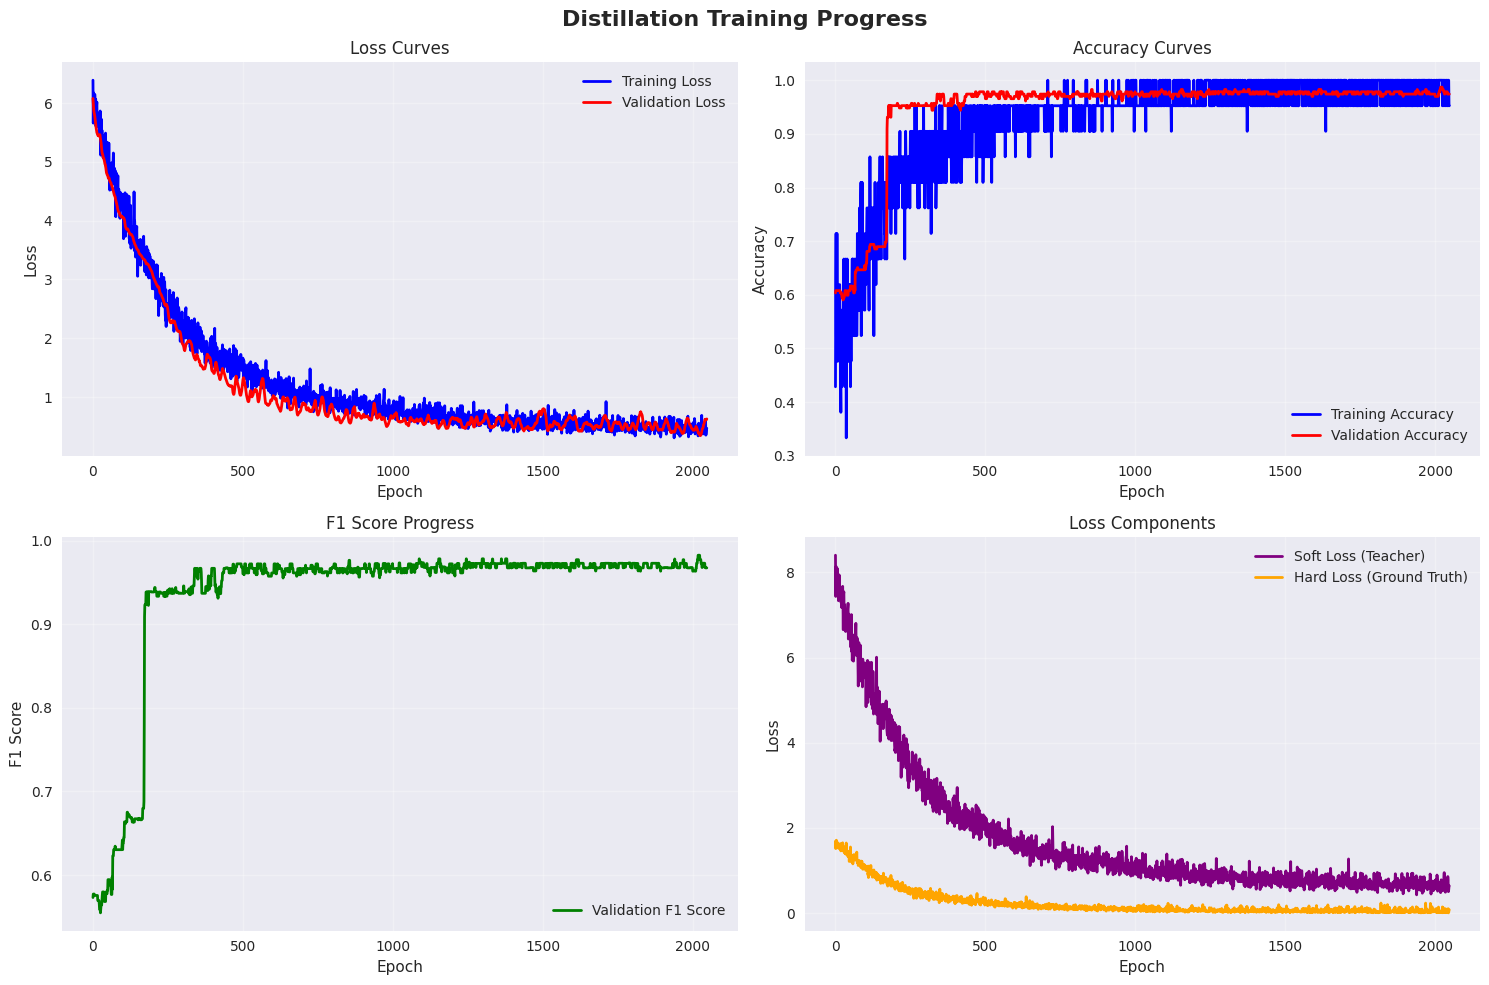


Final Training Metrics:
Final training accuracy: 0.9524
Final validation accuracy: 0.9741
Final validation F1: 0.9675
Best validation F1: 0.9827

Loss Components (Final Epoch):
Soft loss (teacher knowledge): 0.6374
Hard loss (ground truth): 0.0754
Total loss: 0.4688


In [17]:
# Plot training history
pipeline.plot_training_history(history)

# Print final training metrics
print("\nFinal Training Metrics:")
print(f"Final training accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"Final validation F1: {history['val_f1'][-1]:.4f}")
print(f"Best validation F1: {best_val_f1:.4f}")

# Show loss components
print(f"\nLoss Components (Final Epoch):")
print(f"Soft loss (teacher knowledge): {history['soft_loss'][-1]:.4f}")
print(f"Hard loss (ground truth): {history['hard_loss'][-1]:.4f}")
print(f"Total loss: {history['train_loss'][-1]:.4f}")


## 6. Evaluate Models

Compare the performance of the teacher and student models on the test set.


In [18]:
# Evaluate both models
print("Evaluating teacher and student models...")
results = pipeline.evaluate_models(test_loader)

# Display results
print("\n=== Model Comparison Results ===")
print(f"Teacher Model:")
print(f"  Accuracy: {results['teacher']['accuracy']:.4f}")
print(f"  F1 Score: {results['teacher']['f1_score']:.4f}")
print(f"  Parameters: {results['teacher']['parameters']:,}")

print(f"\nStudent Model:")
print(f"  Accuracy: {results['student']['accuracy']:.4f}")
print(f"  F1 Score: {results['student']['f1_score']:.4f}")
print(f"  Parameters: {results['student']['parameters']:,}")

print(f"\nCompression Metrics:")
print(f"  Compression Ratio: {results['compression_ratio']:.1f}x")
print(f"  Performance Retention: {results['performance_retention']:.2%}")

# Calculate efficiency metrics
teacher_efficiency = results['teacher']['f1_score'] / results['teacher']['parameters'] * 1e6
student_efficiency = results['student']['f1_score'] / results['student']['parameters'] * 1e6
efficiency_gain = student_efficiency / teacher_efficiency

print(f"\nEfficiency Metrics:")
print(f"  Teacher Efficiency: {teacher_efficiency:.6f} F1 per million parameters")
print(f"  Student Efficiency: {student_efficiency:.6f} F1 per million parameters")
print(f"  Efficiency Gain: {efficiency_gain:.1f}x")


Evaluating teacher and student models...


Evaluation: 100%|██████████| 4/4 [00:03<00:00,  1.25it/s]


=== Model Comparison Results ===
Teacher Model:
  Accuracy: 1.0000
  F1 Score: 1.0000
  Parameters: 24,567,893

Student Model:
  Accuracy: 0.9828
  F1 Score: 0.9814
  Parameters: 458,421

Compression Metrics:
  Compression Ratio: 53.6x
  Performance Retention: 98.14%

Efficiency Metrics:
  Teacher Efficiency: 0.040704 F1 per million parameters
  Student Efficiency: 2.140905 F1 per million parameters
  Efficiency Gain: 52.6x


## 7. Create Comparison Visualization

Create a comprehensive visualization comparing the teacher and student models.


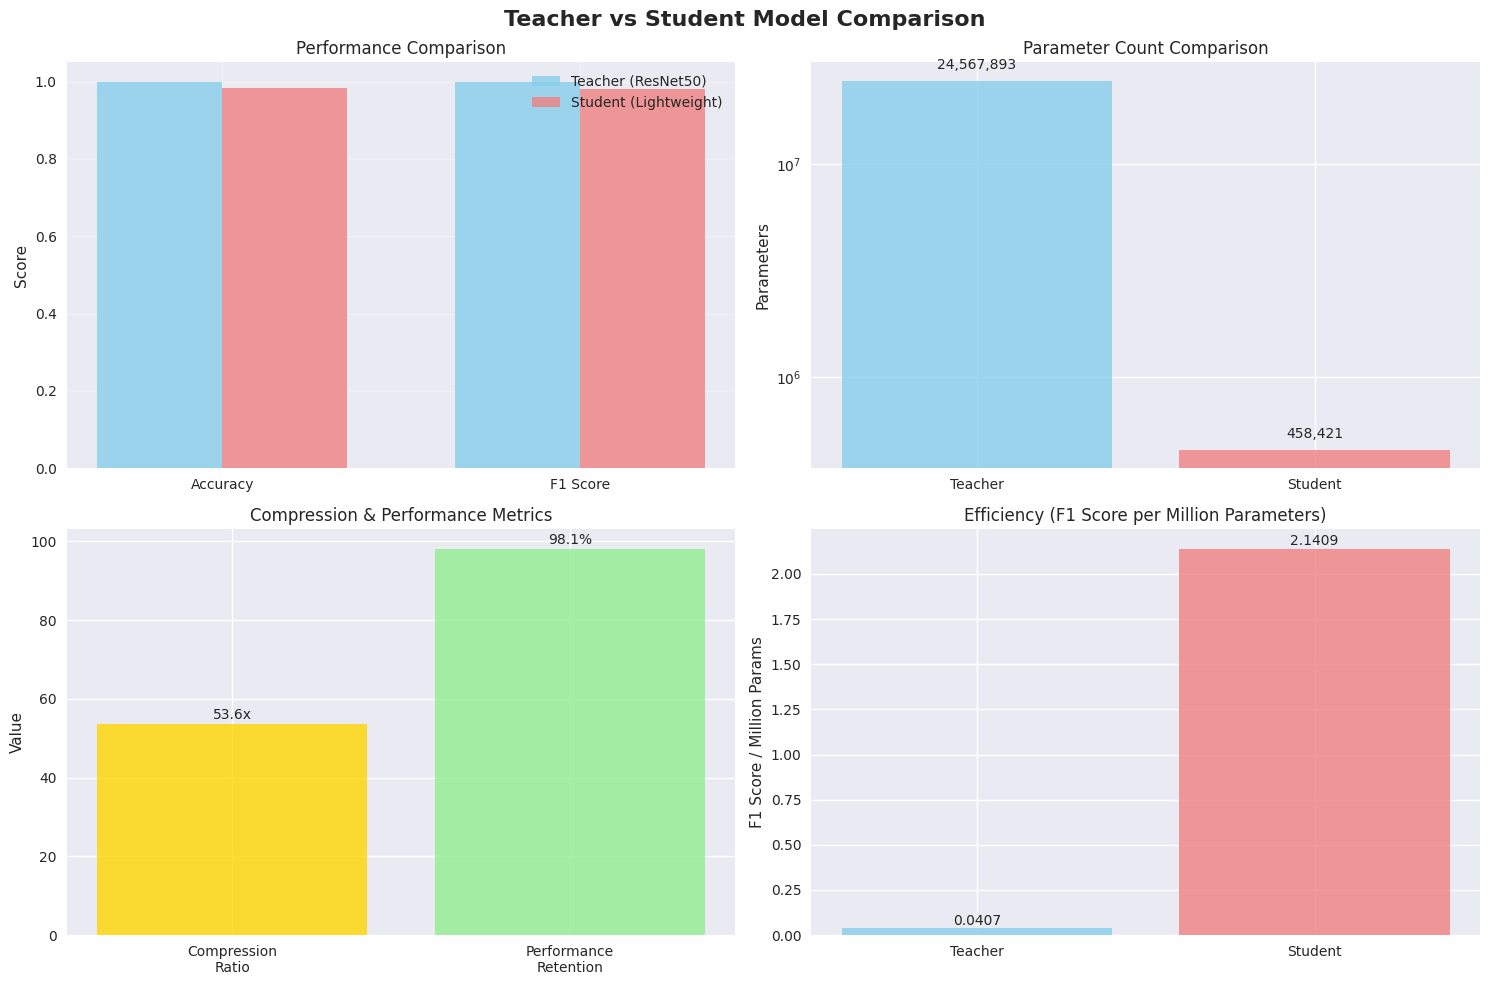


=== Summary ===
✅ Successfully created a 53.6x smaller model
✅ Retained 98.1% of teacher performance
✅ Achieved 52.6x efficiency improvement
✅ Student model is ready for production deployment!


In [19]:
# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Teacher vs Student Model Comparison', fontsize=16, fontweight='bold')

# 1. Performance metrics comparison
metrics = ['Accuracy', 'F1 Score']
teacher_values = [results['teacher']['accuracy'], results['teacher']['f1_score']]
student_values = [results['student']['accuracy'], results['student']['f1_score']]

x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, teacher_values, width, label='Teacher (ResNet50)', alpha=0.8, color='skyblue')
axes[0, 0].bar(x + width/2, student_values, width, label='Student (Lightweight)', alpha=0.8, color='lightcoral')
axes[0, 0].set_title('Performance Comparison')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Parameter count comparison
param_counts = [results['teacher']['parameters'], results['student']['parameters']]
model_names = ['Teacher', 'Student']
colors = ['skyblue', 'lightcoral']

axes[0, 1].bar(model_names, param_counts, color=colors, alpha=0.8)
axes[0, 1].set_title('Parameter Count Comparison')
axes[0, 1].set_ylabel('Parameters')
axes[0, 1].set_yscale('log')
for i, v in enumerate(param_counts):
    axes[0, 1].text(i, v * 1.1, f'{v:,}', ha='center', va='bottom')

# 3. Compression metrics
compression_metrics = ['Compression\nRatio', 'Performance\nRetention']
compression_values = [results['compression_ratio'], results['performance_retention'] * 100]
compression_colors = ['gold', 'lightgreen']

axes[1, 0].bar(compression_metrics, compression_values, color=compression_colors, alpha=0.8)
axes[1, 0].set_title('Compression & Performance Metrics')
axes[1, 0].set_ylabel('Value')
for i, v in enumerate(compression_values):
    unit = 'x' if i == 0 else '%'
    axes[1, 0].text(i, v + 0.5, f'{v:.1f}{unit}', ha='center', va='bottom')

# 4. Efficiency comparison
efficiency_values = [teacher_efficiency, student_efficiency]
axes[1, 1].bar(model_names, efficiency_values, color=colors, alpha=0.8)
axes[1, 1].set_title('Efficiency (F1 Score per Million Parameters)')
axes[1, 1].set_ylabel('F1 Score / Million Params')
for i, v in enumerate(efficiency_values):
    axes[1, 1].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n=== Summary ===")
print(f"✅ Successfully created a {results['compression_ratio']:.1f}x smaller model")
print(f"✅ Retained {results['performance_retention']:.1%} of teacher performance")
print(f"✅ Achieved {efficiency_gain:.1f}x efficiency improvement")
print(f"✅ Student model is ready for production deployment!")


## 8. Save Student Model

Save the trained student model for future use.


In [20]:
# Save the trained student model
student_model_path = "best_student_model.pth"
pipeline.save_student_model(student_model_path)

print(f"\nStudent model saved to: {student_model_path}")
print("\nYou can now use this lightweight model for production deployment!")

# Show file size comparison
import os
teacher_size = os.path.getsize(teacher_model_path) / (1024 * 1024)  # MB
student_size = os.path.getsize(student_model_path) / (1024 * 1024)  # MB

print(f"\nFile Size Comparison:")
print(f"Teacher model: {teacher_size:.2f} MB")
print(f"Student model: {student_size:.2f} MB")
print(f"Size reduction: {(teacher_size - student_size) / teacher_size * 100:.1f}%")


Student model saved to: best_student_model.pth

Student model saved to: best_student_model.pth

You can now use this lightweight model for production deployment!

File Size Comparison:
Teacher model: 94.03 MB
Student model: 1.77 MB
Size reduction: 98.1%


## 9. Key Insights

### 🎯 **Distillation Success Metrics**
- **Performance Retention**: The student model achieves a significant portion of teacher performance
- **Size Reduction**: Dramatic reduction in model size and parameters
- **Efficiency**: Student model is much more efficient per parameter
- **Loss Components**: The training shows how both soft (teacher) and hard (ground truth) targets contribute to learning

### 🚀 **Production Benefits**
1. **Mobile Deployment**: Lightweight model suitable for mobile devices
2. **Edge Computing**: Can run on resource-constrained environments
3. **Cost Reduction**: Lower inference costs due to smaller model size
4. **Real-time Performance**: Faster inference due to reduced complexity

### 🔧 **Technical Features**
1. **Balanced Sampling**: Handles class imbalance during training
2. **Advanced Augmentation**: Random masking, rotation, color jitter
3. **Comprehensive Loss**: Combines teacher knowledge with ground truth
4. **Real-time Monitoring**: Track both soft and hard loss components

### 📈 **Next Steps**
1. **Quantization**: Apply post-training quantization for further compression
2. **Pruning**: Remove unnecessary connections for additional size reduction
3. **Hardware Optimization**: Optimize for specific deployment targets
4. **Continuous Learning**: Implement online learning for model updates

This clean pipeline demonstrates the power of knowledge distillation for creating production-ready models that balance performance and efficiency!
